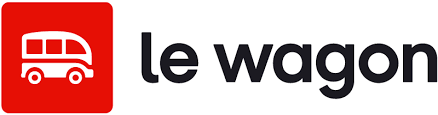

# Dataset

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


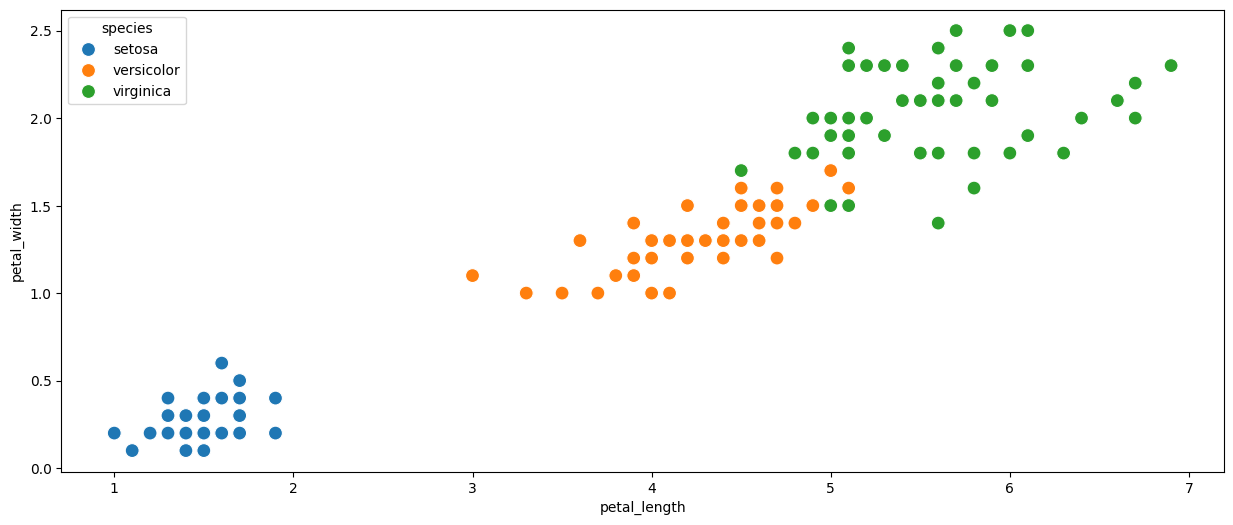

In [21]:
plt.figure(figsize=(15,6))
sns.scatterplot(iris,
                x='petal_length',
                y='petal_width',
                hue='species',
                s=100);

# Unsupervised Learning

In [22]:
# Removing the target from our dataset
y = iris.pop('species')
X = iris
X.head(1)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2


## Clustering with K-Means

In [23]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X)
kmeans_pred = kmeans.labels_

In [24]:
kmeans.cluster_centers_

array([[5.006     , 3.428     , 1.462     , 0.246     ],
       [5.9016129 , 2.7483871 , 4.39354839, 1.43387097],
       [6.85      , 3.07368421, 5.74210526, 2.07105263]])

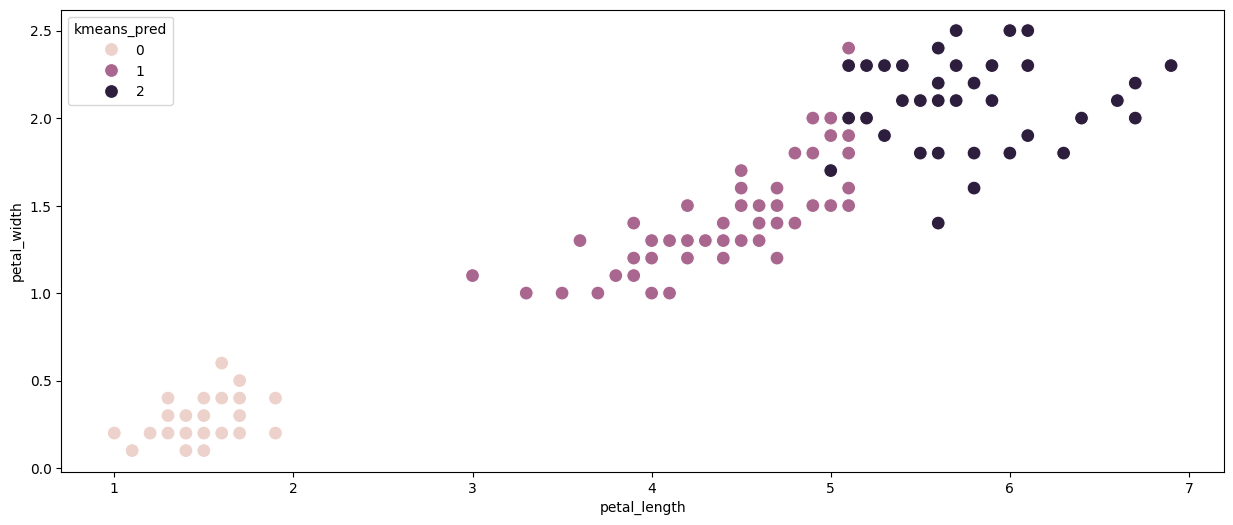

In [38]:
# Merge dataframes to plot
kmeans_preds = pd.merge(X,
                        pd.DataFrame(kmeans_pred, columns=['kmeans_pred']),
                        left_index=True, right_index=True)

# Plot
plt.figure(figsize=(15,6))
sns.scatterplot(kmeans_preds,
                x='petal_length',
                y='petal_width',
                hue='kmeans_pred',
                s=100);

In [39]:
kmeans.inertia_

27.14639225068018

### Elbow method

In [40]:
list(range(1,11))

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [41]:
inertias = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, n_init='auto')
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

inertias

[681.3706,
 152.3479517603579,
 78.851441426146,
 57.38387326549494,
 51.08942414529915,
 42.09902883597884,
 37.517100877193,
 30.303211839759825,
 28.756828208023855,
 28.116743306693305]

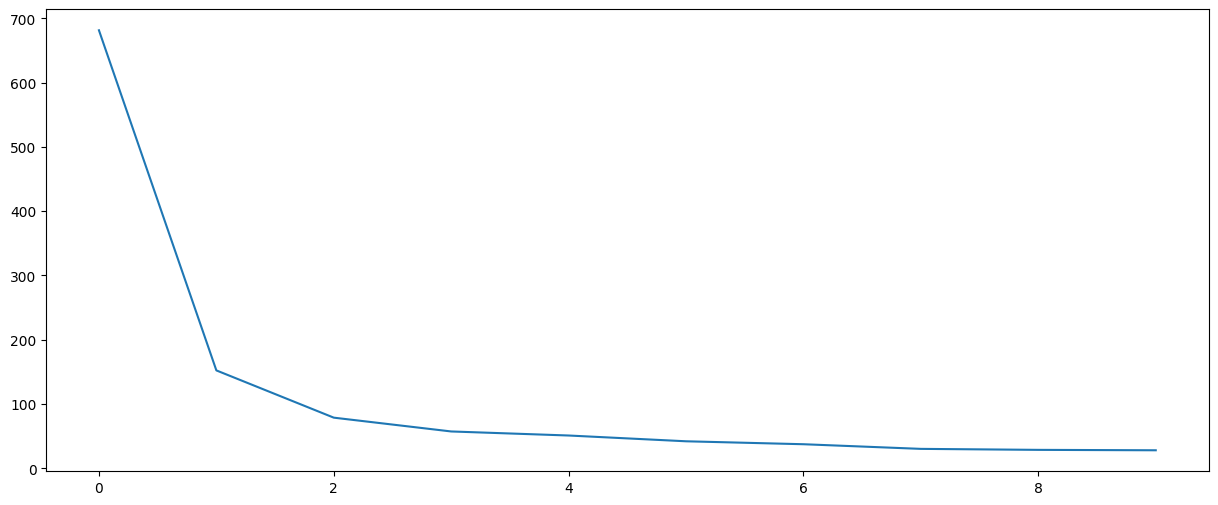

In [42]:
plt.figure(figsize=(15,6))
sns.lineplot(inertias);

## Clustering DBSCAN

In [43]:
from sklearn.cluster import DBSCAN

clustering = DBSCAN().fit(X)

clustering.labels_

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  1,
        1,  1,  1,  1,  1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1,  1,
        1,  1,  1, -1, -1,  1, -1, -1,  1,  1,  1,  1,  1,  1,  1, -1, -1,
        1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1, -1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1])

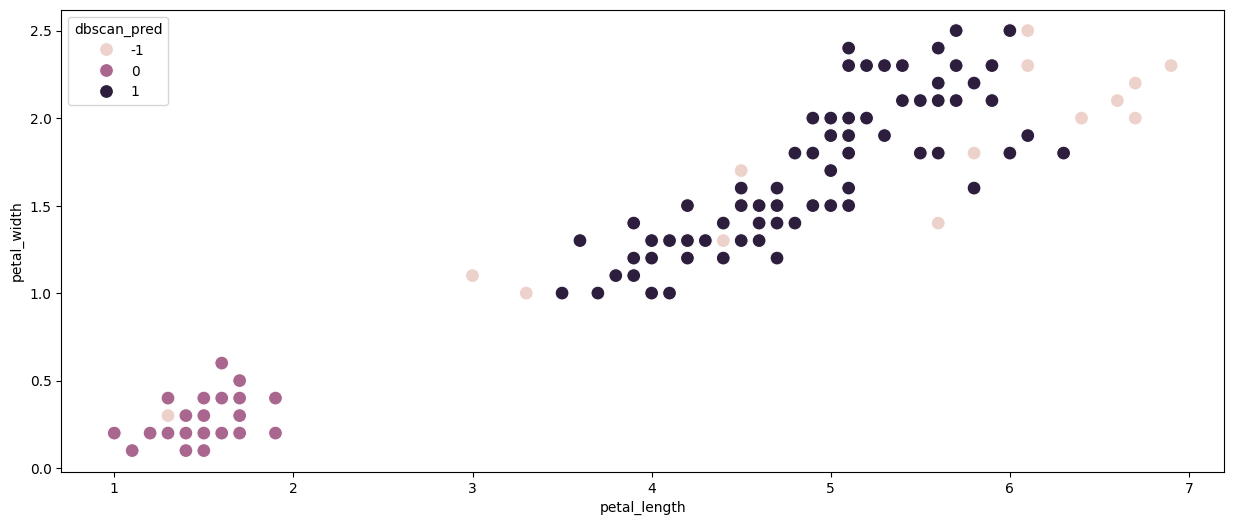

In [44]:
# Merge dataframes to plot
dbscan_preds = pd.merge(X,
                        pd.DataFrame(clustering.labels_, columns=['dbscan_pred']),
                        left_index=True,
                        right_index=True)

# Plot
plt.figure(figsize=(15,6))
sns.scatterplot(dbscan_preds,
                x='petal_length',
                y='petal_width',
                hue='dbscan_pred',
                s=100);